In [1]:
import torch
import random
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# ---------------------------------------------------------------------------*/
# - prepare a dataset

# define known data properties
timeseries_len = 51
timestep = 0.02

# read training data from a file
data_train = utils.read_datafile('pendulum/train6', timeseries_len)
data_ch_n = data_train.shape[-1]
print(f"inf >> training data consists of {data_train.shape[0]} batches, where each batch has {data_train.shape[2]} data channels and {data_train.shape[1]} time steps")

# read validation data from file
data_valid = utils.read_datafile('pendulum/valid', timeseries_len)
print(f"inf >> validation data consists of {data_valid.shape[0]} batches, where each batch has {data_valid.shape[2]} data channels and {data_valid.shape[1]} time steps")

# read test data from file
data_test = utils.read_datafile('pendulum/test', timeseries_len)
print(f"inf >> test data consists of {data_test.shape[0]} batches, where each batch has {data_test.shape[2]} data channels and {data_test.shape[1]} time steps")

inf >> training data consists of 3500 batches, where each batch has 2 data channels and 51 time steps
inf >> validation data consists of 1000 batches, where each batch has 2 data channels and 51 time steps
inf >> test data consists of 500 batches, where each batch has 2 data channels and 51 time steps


In [3]:
# ---------------------------------------------------------------------------*/
# - instantiate dynamical mode decomposition

# we say that it is enough to use 2 dimensions (data channels) to describe a single
# harmonic oscillator in terms of rotation on a 2-dimensional plane
latent_ch_n = 2

config = {
    'data_ch_n'     : data_ch_n,
    'latent_ch_n'   : latent_ch_n,
    'act'           : 'relu',
    'timestep'      : timestep,
    'loss_reg_l2'   : 1e-10
}

model = care.dmd(config)

inf >> number of data files for training : 5
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5


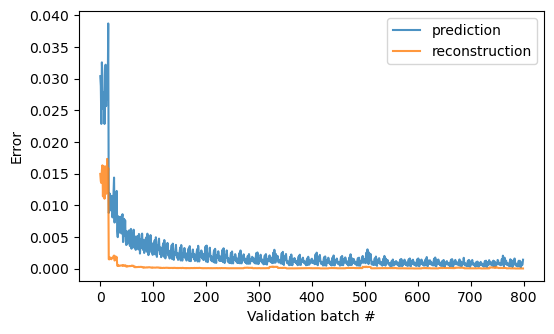

In [4]:
# ---------------------------------------------------------------------------*/
# - training and validation

batch_size = 64

# make validation datasets and loaders
dataset_valid = torch.utils.data.TensorDataset(data_valid)
dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)

# specify optimizer and a loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# specify the length of our validated prediction
prediction_steps_n = timeseries_len

mse_valid_pred = []
mse_valid_recon = []

datafiles_train_n = random.randint(3, 6)
print(f"inf >> number of data files for training : {datafiles_train_n}")

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")
    data_train = utils.read_datafile(f'pendulum/train{datafile_train + 1}', timeseries_len)

    # make training datasets and loaders
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

    # train
    for epoch in range(10):
        # train neural networks
        for data_batch in dataloader_train:
            timeseries_batch = data_batch[0]

            optimizer.zero_grad()

            loss = model.fit(timeseries_batch)
            loss.backward()

            optimizer.step()

        # validate results
        with torch.no_grad():
            for data_batch in dataloader_valid:
                timeseries_i_batch = data_batch[0]

                # validate prediction
                timeseries_o_batch = torch.stack(
                    [model.predict(timeseries[torch.newaxis, 0], prediction_steps_n) for timeseries in timeseries_i_batch])
                mse_valid_pred.append(torch.mean((timeseries_i_batch - timeseries_o_batch)**2))

                # validate reconstruction
                timeseries_o_batch = model.autoencoder(timeseries_i_batch)
                mse_valid_recon.append(torch.mean((timeseries_i_batch - timeseries_o_batch)**2))

with torch.no_grad():
    plt.figure(figsize=(6, 3.5))
    plt.plot(mse_valid_pred, alpha=0.8, label='prediction')
    plt.plot(mse_valid_recon, alpha=0.8, label='reconstruction')
    plt.xlabel("Validation batch #")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

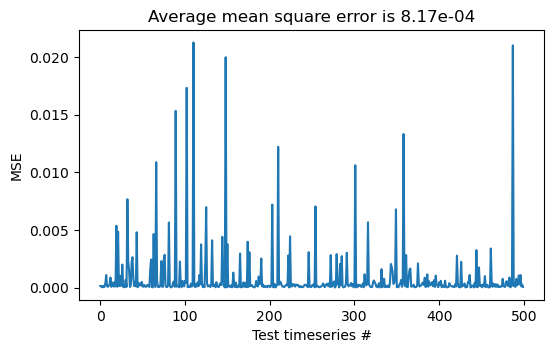

In [5]:
# ---------------------------------------------------------------------------*/
# - test results : check prediction on test data

mse_test_pred = []

for timeseries_i in data_test:
    timeseries_o = model.predict(timeseries_i[torch.newaxis, 0], timeseries_len)
    mse_test_pred.append(torch.mean((timeseries_i - timeseries_o)**2))

with torch.no_grad():
    avg_mse_test_pred = np.mean(mse_test_pred)

    plt.figure(figsize=(6, 3.5))
    plt.title(f"Average mean square error is {avg_mse_test_pred:.2e}")
    plt.plot(mse_test_pred)
    plt.xlabel("Test timeseries #")
    plt.ylabel("MSE")
    plt.show()

Eigenvalues range from 0.17 to 0.98


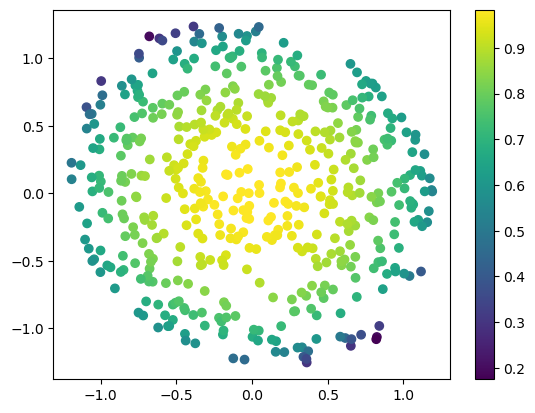

In [6]:
# ---------------------------------------------------------------------------*/
# - test results : check the properties of latent coordinates

coords_batch = torch.stack([model.autoencoder.encoder(timeseries[torch.newaxis, 0]) for timeseries in data_test], dim=0)
eigens_batch = model.eigenvalues(coords_batch)

coords = torch.reshape(coords_batch, (coords_batch.shape[0], coords_batch.shape[2]))
eigens = torch.reshape(eigens_batch, (eigens_batch.shape[0], eigens_batch.shape[2]))

with torch.no_grad():
    eigen_min = torch.min(eigens)
    eigen_max = torch.max(eigens)
    print(f"Eigenvalues range from {eigen_min:.2f} to {eigen_max:.2f}")

    colors = eigens[:, 0]

    plt.figure()
    plt.scatter(coords[:, 0], coords[:, 1], c=colors)
    plt.colorbar()
    plt.show()


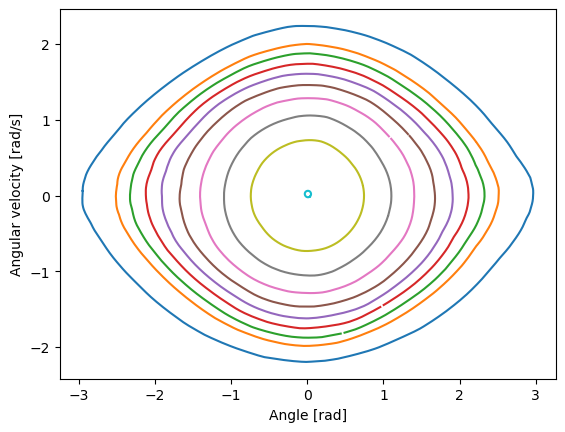

In [36]:
with torch.no_grad():
    # retrieve frequencies for all initial conditions
    eigens = torch.stack(
        [model.eigenvalues(
            model.autoencoder.encoder(timeseries[torch.newaxis, 0])) for timeseries in data_test], dim=0)

    # sort frequencies in ascending order
    eigens, indices = torch.sort(eigens, dim=0)

    # select the indices of n evenly spaced frequencies for plotting
    eigens_j = torch.linspace(0, len(eigens) - 1, 10, dtype=int)

    plt.figure()
    for eigen_j in eigens_j:
        # from angular velocity derive the number of prediction steps for the whole period
        predict_steps_n = int(1/(eigens[eigen_j]/(2*torch.pi))/timestep)
        timeseries_i = torch.squeeze(data_test[indices[eigen_j]])

        # predict the whole period from a given initial condition
        timeseries_o = model.predict(timeseries_i[torch.newaxis, 0], predict_steps_n)
        plt.plot(timeseries_o[:, 0], timeseries_o[:, 1])
    plt.xlabel("Angle [rad]")
    plt.ylabel("Angular velocity [rad/s]")
    plt.show()
